In [10]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
rng = np.random.default_rng()

def bernoulli_generation(p, size):
    return rng.binomial(1, p, size=size)

def bernoulli_mle(data):
    return np.sum(data) / len(data)

def ab_test():
    group_A = bernoulli_generation(0.12, 200)
    group_B = bernoulli_generation(0.14, 200)

    A_mle = bernoulli_mle(group_A)
    B_mle = bernoulli_mle(group_B)

    ttest = st.ttest_ind(group_A, group_B)

    print("Group A conversion: ", A_mle, " Group B conversion: ", B_mle)
    print("Observed Difference: ", np.abs(A_mle - B_mle))
    print("t-statistic: ", ttest[0], " p-value: ", ttest[1])
    if ttest[1] > 0.05:
        print("Result: NOT significant at α=0.05")
    else:
        print("Result: Significant at α=0.05")
    
ab_test()


Group A conversion:  0.13  Group B conversion:  0.135
Observed Difference:  0.0050000000000000044
t-statistic:  -0.14711287110960772  p-value:  0.8831174224649643
Result: NOT significant at α=0.05


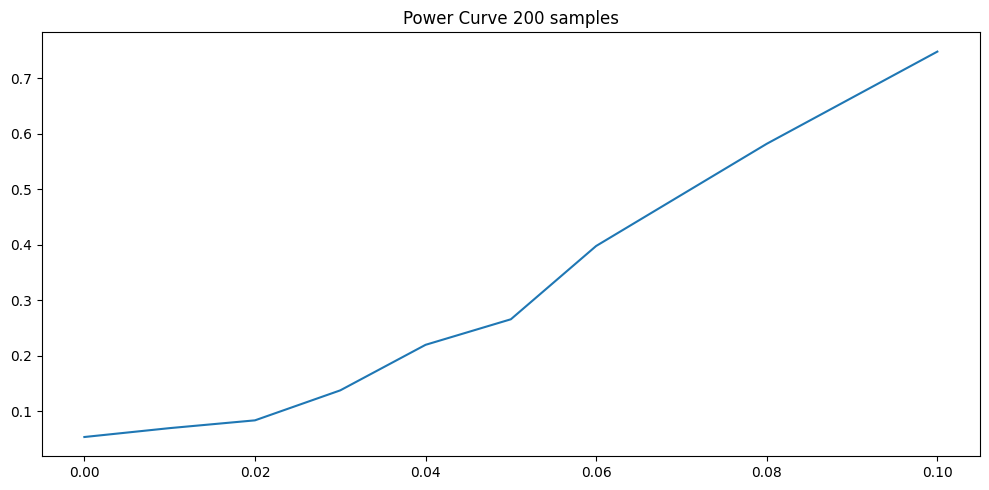

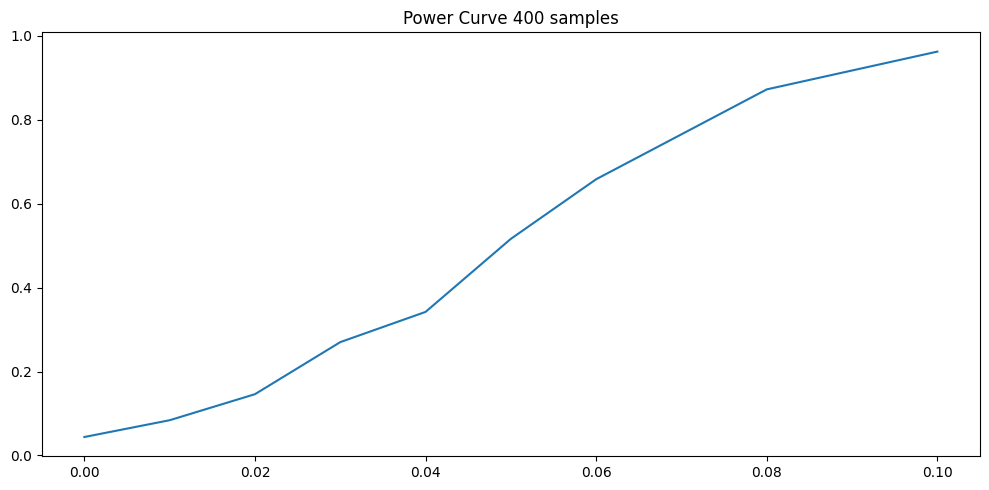

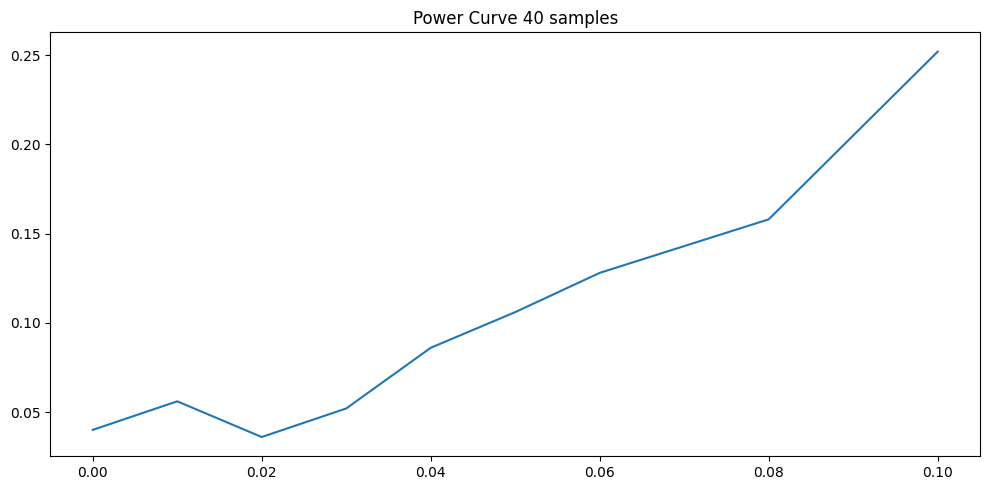

array([0.04 , 0.056, 0.036, 0.052, 0.086, 0.106, 0.128, 0.158, 0.252])

In [3]:

true_differences = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10]

def compute_power_curve(diffs, p=0.12, n=200, exps=500):
    total_rejections = []
    for dif in diffs:
        rejections = 0
        for _ in range(exps):
            control = bernoulli_generation(p, n)
            variant = bernoulli_generation(p+dif, n)
            ttest = st.ttest_ind(control, variant)
            if ttest[1] < 0.05:
                rejections +=1

        total_rejections.append(rejections)

    total_rejections = np.array(total_rejections) / exps
    plot_power_curve(total_rejections, diffs, n)
    
    return total_rejections

def plot_power_curve(rejections, differences, n):
    plt.figure(figsize=(10,5))
    plt.plot(differences, rejections)
    title = "Power Curve " + str(n) +" samples"
    plt.title(title) 
    plt.tight_layout()
    plt.show()

compute_power_curve(true_differences)
compute_power_curve(true_differences, n=400)
compute_power_curve(true_differences, n=40)

In [43]:

variants = np.concatenate([np.array([0.04, 0.06]), np.zeros(8)])

def bonf_correction(p_vals, a=0.05):
    m = len(p_vals)
    return [p < a / m for p in p_vals]

def bh_correction(p_vals, a=0.05):
    m = len(p_vals)
    sorted_indices = np.argsort(p_vals)
    sorted_p = np.array(p_vals)[sorted_indices]
    
    ranks = np.arange(1, m + 1)
    critical_values = (ranks / m) * a
    
    rejection_matches = sorted_p <= critical_values
    
    if not any(rejection_matches):
        return [False] * m
        
    max_k = np.max(np.where(rejection_matches))
    
    rejections = [False] * m
    for i in range(max_k + 1):
        original_idx = sorted_indices[i]
        rejections[original_idx] = True
        
    return rejections

def run_simulation(n_sims=500):
    variants_diffs = np.array([0.04, 0.06, 0, 0, 0, 0, 0, 0, 0, 0])
    stats = {'bonf_tp': 0, 'bonf_fp': 0, 'bh_tp': 0, 'bh_fp': 0}

    for _ in range(n_sims):
        control = bernoulli_generation(0.12, 500)
        p_values = []
        
        for diff in variants_diffs:
            variant = bernoulli_generation(0.12 + diff, 500)
            p_val = st.ttest_ind(variant, control)[1]
            p_values.append(p_val)
            
        bonf_res = bonf_correction(p_values)
        bh_res = bh_correction(p_values)
        
        for i in range(10):
            if i < 2:
                if bonf_res[i]: stats['bonf_tp'] += 1
                if bh_res[i]: stats['bh_tp'] += 1
            else: # Noise
                if bonf_res[i]: stats['bonf_fp'] += 1
                if bh_res[i]: stats['bh_fp'] += 1

    print(f"--- Results over {n_sims} simulations ---")
    print(f"Bonferroni: Avg TP: {stats['bonf_tp']/n_sims:.2f}/2, Avg FP: {stats['bonf_fp']/n_sims:.2f}/8")
    print(f"BH:         Avg TP: {stats['bh_tp']/n_sims:.2f}/2, Avg FP: {stats['bh_fp']/n_sims:.2f}/8")

run_simulation()

--- Results over 500 simulations ---
Bonferroni: Avg TP: 0.62/2, Avg FP: 0.03/8
BH:         Avg TP: 0.68/2, Avg FP: 0.10/8


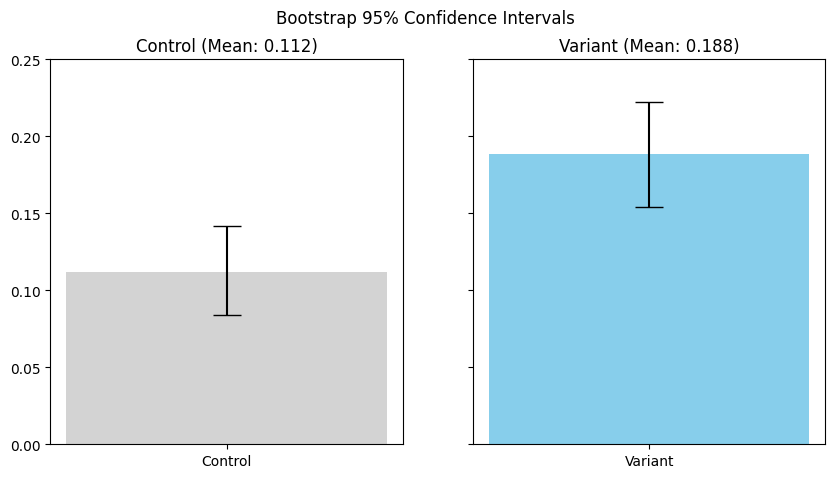

In [53]:

def bootstrap_ci(data, n_resamples=1000, ci=0.95):
    length = len(data)
    sample_means = []

    for _ in range(n_resamples):
        n_sample = np.random.choice(data, size=500, replace=True)
        sample_means.append(np.mean(n_sample))

    lower = (1 - ci) / 2
    higher = ci + lower
    intervals = np.percentile(sample_means, [lower * 100, higher * 100])
    return {
        'mean': np.mean(sample_means),
        'lower': np.mean(intervals[0]),
        'upper': np.mean(intervals[1]),
        'all_means': sample_means}
    
    

def compute_bootstrap():
    control = bernoulli_generation(0.12, 500)
    variant = bernoulli_generation(0.16, 500)
    control_bootstrap = bootstrap_ci(control)
    variant_bootstrap = bootstrap_ci(variant)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
    
    def get_error(res):
        return [[res['mean'] - res['lower']], [res['upper'] - res['mean']]]

    ax1.bar('Control', control_bootstrap['mean'], yerr=get_error(control_bootstrap), capsize=10, color='lightgray')
    ax1.set_title(f"Control (Mean: {control_bootstrap['mean']:.3f})")
    
    ax2.bar('Variant', variant_bootstrap['mean'], yerr=get_error(variant_bootstrap), capsize=10, color='skyblue')
    ax2.set_title(f"Variant (Mean: {variant_bootstrap['mean']:.3f})")

    plt.ylim(0, 0.25)
    plt.suptitle("Bootstrap 95% Confidence Intervals")
    plt.show()


compute_bootstrap()